In [1]:
# Seasonal Agriculture Performance Analysis

"""
This project analyzes agricultural performance across different seasons,
regions, crops, environmental conditions, resource usage, and economic outcomes.
"""

'\nThis project analyzes agricultural performance across different seasons,\nregions, crops, environmental conditions, resource usage, and economic outcomes.\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [3]:
import os
os.listdir()

['.ipynb_checkpoints',
 'Seasonal_Agriculture_Performance_Analysis.ipynb',
 'seasonal_agriculture_performance_dataset.csv']

In [4]:
import pandas as pd

df = pd.read_csv("seasonal_agriculture_performance_dataset.csv")

df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [5]:
df.shape

(4000, 28)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [7]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 4000
Number of Columns: 28


In [8]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [9]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [10]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [11]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [12]:
print("States:")
print(df["State"].unique())

print("\nCrops:")
print(df["Crop"].unique())

print("\nSeasons:")
print(df["Season"].unique())

print("\nIrrigation Methods:")
print(df["Irrigation_Method"].unique())

States:
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

Crops:
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Seasons:
['Kharif' 'Rabi' 'Zaid']

Irrigation Methods:
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [13]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [14]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage[missing_percentage > 0]

Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64

In [15]:
df["Rainfall_mm"] = df["Rainfall_mm"].fillna(
    df["Rainfall_mm"].median()
)

df["Soil_Moisture_pct"] = df["Soil_Moisture_pct"].fillna(
    df["Soil_Moisture_pct"].median()
)

df["Yield_Tonnes_Ha"] = df["Yield_Tonnes_Ha"].fillna(
    df["Yield_Tonnes_Ha"].median()
)

In [94]:
### 1.1 Missing Value Analysis

Missing values are identified to ensure data quality before analysis.

In [18]:
df_clean = df.copy()

df_clean.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [19]:
df_clean.isnull().sum()

Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct            0
dtype: int64

In [20]:
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100

missing_percentage.sort_values(ascending=False)

Farm_ID                          0.0
State                            0.0
District                         0.0
Crop                             0.0
Season                           0.0
Farm_Area_Hectares               0.0
Rainfall_mm                      0.0
Avg_Temperature_C                0.0
Humidity_pct                     0.0
Sunlight_Hours_Day               0.0
Soil_pH                          0.0
Soil_Moisture_pct                0.0
Nitrogen_kg_ha                   0.0
Phosphorus_kg_ha                 0.0
Potassium_kg_ha                  0.0
Irrigation_Method                0.0
Fertilizer_kg_ha                 0.0
Pesticide_Litre_ha               0.0
Seed_Quality_Score               0.0
Yield_Tonnes_Ha                  0.0
Production_Tonnes                0.0
Market_Price_INR_Tonne           0.0
Total_Cost_INR                   0.0
Revenue_INR                      0.0
Profit_INR                       0.0
Water_Used_m3                    0.0
Water_Efficiency_t_per_1000m3    0.0
D

In [21]:
missing_columns = [
    "Rainfall_mm",
    "Soil_Moisture_pct",
    "Yield_Tonnes_Ha"
]

for col in missing_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [22]:
df_clean[missing_columns].isnull().sum()

Rainfall_mm          0
Soil_Moisture_pct    0
Yield_Tonnes_Ha      0
dtype: int64

Missing numerical values were handled using median imputation. 
Median was selected because it is less affected by extreme values.

In [25]:
df_clean.duplicated().sum()

np.int64(0)

Duplicate records were identified and removed to avoid repeated observations during analysis.

In [28]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    4000 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              4000 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [29]:
df_clean.dtypes

Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

In [30]:
numerical_columns = df_clean.select_dtypes(include="number").columns

numerical_columns

Index(['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C',
       'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
       'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

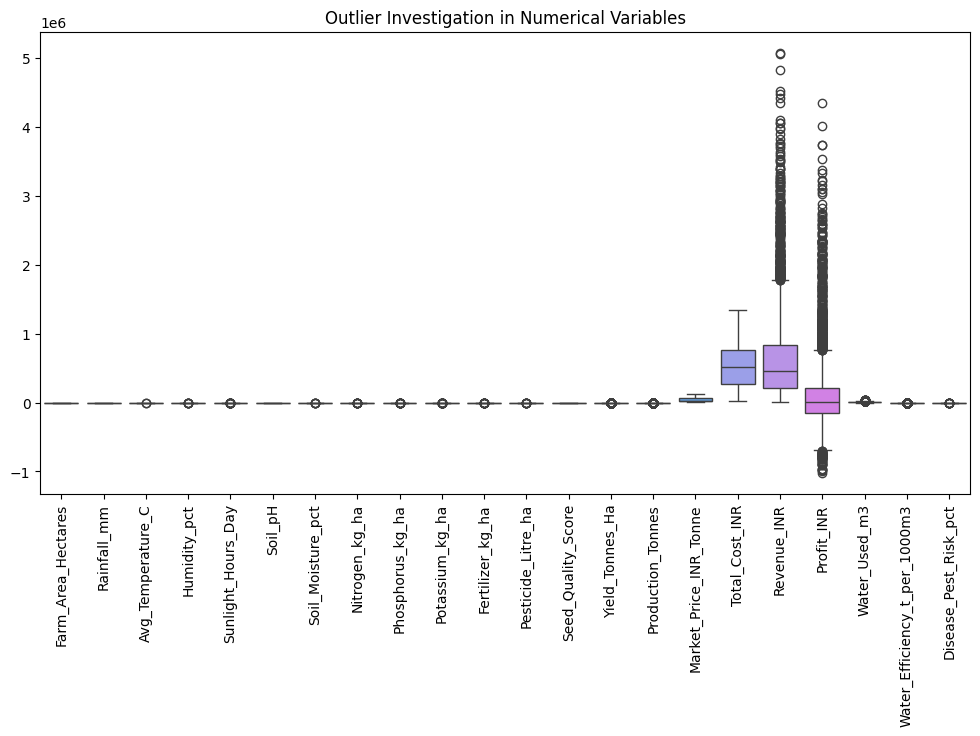

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(data=df_clean[numerical_columns])
plt.xticks(rotation=90)
plt.title("Outlier Investigation in Numerical Variables")
plt.show()

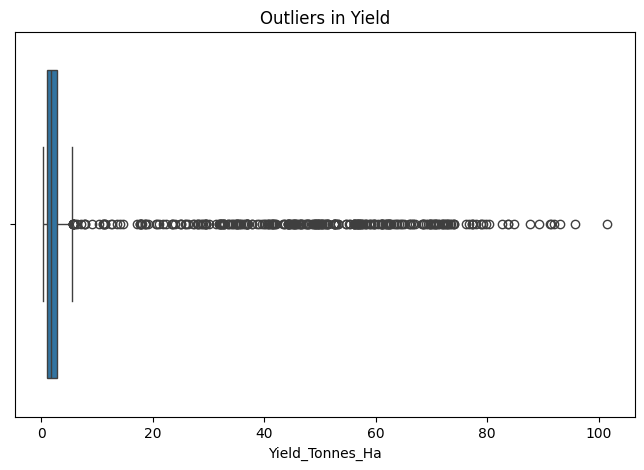

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean["Yield_Tonnes_Ha"])
plt.title("Outliers in Yield")
plt.show()

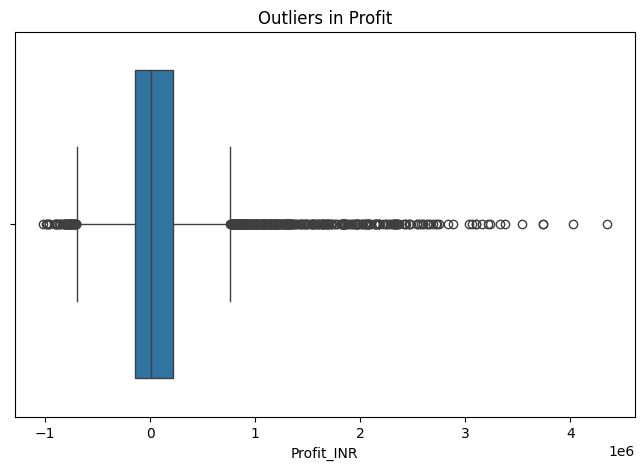

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean["Profit_INR"])
plt.title("Outliers in Profit")
plt.show()


Boxplots were used to investigate the presence of potential outliers. 
Extreme observations were reviewed rather than automatically removed because they may represent genuine agricultural conditions.

In [35]:
df_clean.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,600.922825,26.81890,63.210500,7.323050,6.701010,26.507150,120.250825,57.781850,104.760050,...,0.826138,5.242350,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,287.193381,3.81818,11.960834,1.121186,0.641461,6.678837,31.216452,17.015074,27.742681,...,0.101747,13.311549,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,371.575000,23.90000,54.775000,6.600000,6.260000,21.800000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,831.975000,29.60000,71.900000,8.100000,7.140000,31.200000,141.225000,69.400000,123.600000,...,0.910000,2.830000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


Descriptive Statistics
Descriptive statistics were calculated to understand the central tendency, variability and range of the numerical variables.

In [37]:
df_clean[numerical_columns].describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [38]:
categorical_columns = df_clean.select_dtypes(include="object").columns

categorical_columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method'], dtype='object')

In [39]:
for col in categorical_columns:
    print("\n", col)
    print(df_clean[col].unique())


 Farm_ID
['SF10001' 'SF10002' 'SF10003' ... 'SF13998' 'SF13999' 'SF14000']

 State
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

 District
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

 Crop
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

 Season
['Kharif' 'Rabi' 'Zaid']

 Irrigation_Method
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [40]:
df_clean["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

In [41]:
df_clean["Crop"].value_counts()

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64

In [42]:
df_clean["State"].value_counts()

State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64

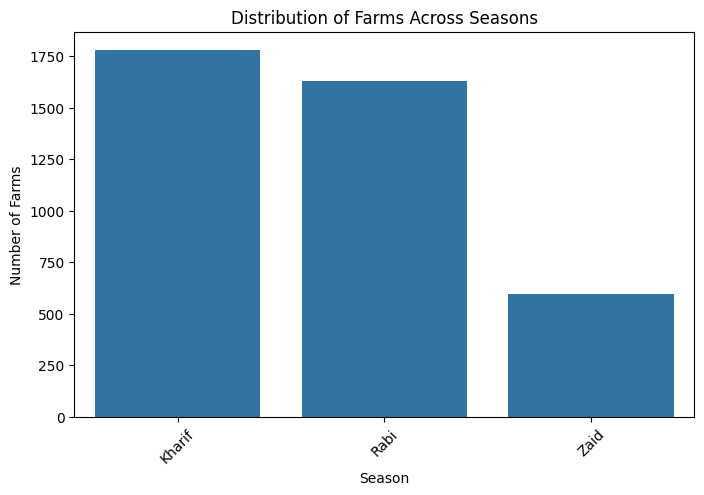

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x="Season")

plt.title("Distribution of Farms Across Seasons")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

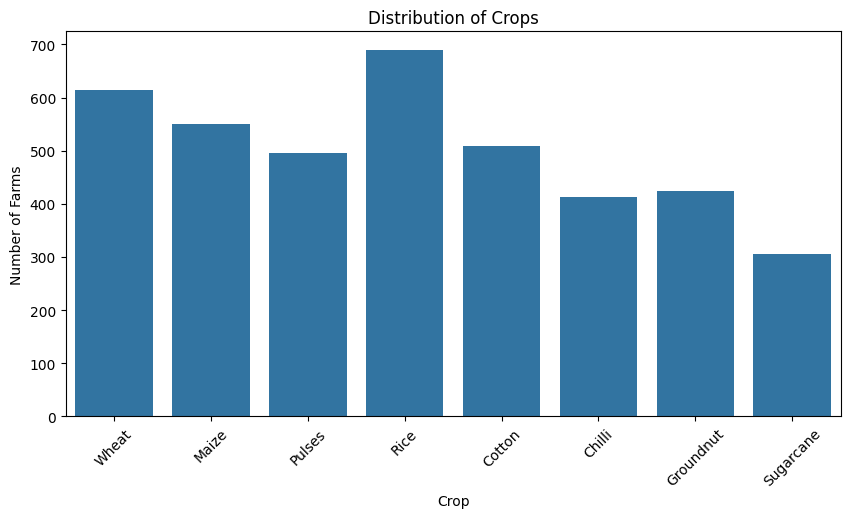

In [44]:
plt.figure(figsize=(10,5))

sns.countplot(data=df_clean, x="Crop")

plt.title("Distribution of Crops")
plt.xlabel("Crop")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

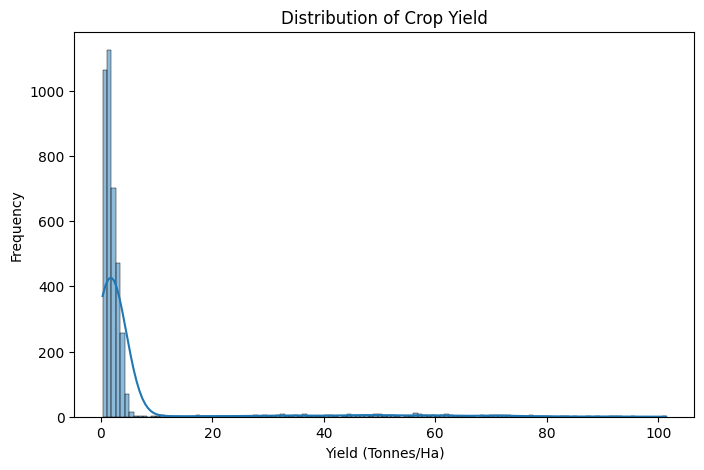

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Yield_Tonnes_Ha"], kde=True)

plt.title("Distribution of Crop Yield")
plt.xlabel("Yield (Tonnes/Ha)")
plt.ylabel("Frequency")
plt.show()

In [46]:
season_yield = df_clean.groupby("Season")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

season_yield

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64

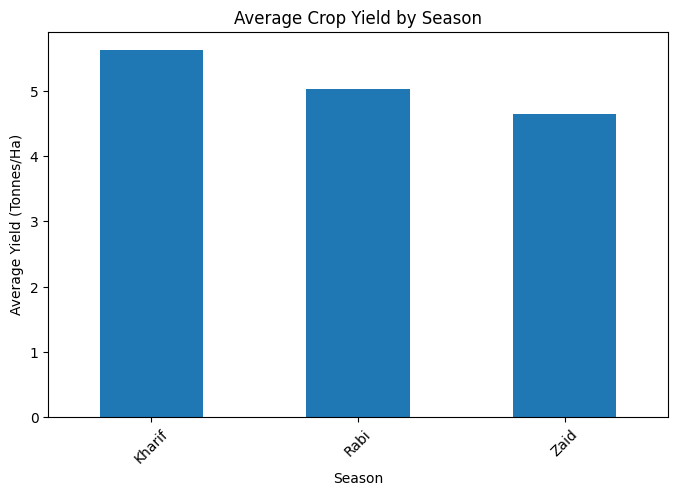

In [47]:
plt.figure(figsize=(8,5))

season_yield.plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [48]:
season_production = df_clean.groupby("Season")["Production_Tonnes"].sum()

season_production

Season
Kharif    82387.61
Rabi      67498.88
Zaid      23098.35
Name: Production_Tonnes, dtype: float64

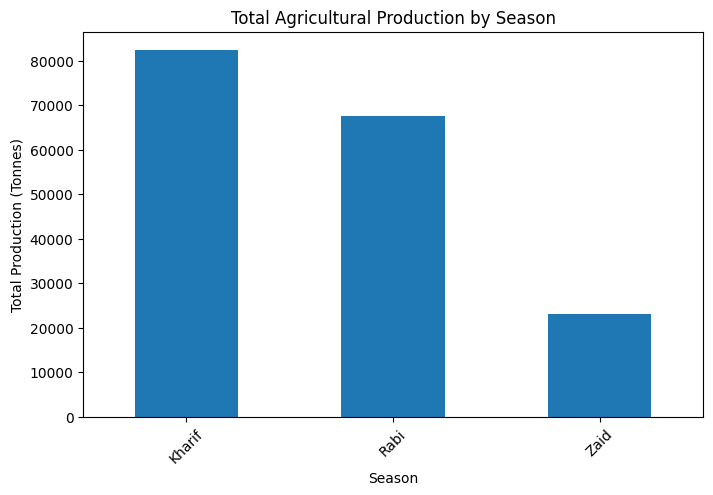

In [49]:
plt.figure(figsize=(8,5))

season_production.plot(kind="bar")

plt.title("Total Agricultural Production by Season")
plt.xlabel("Season")
plt.ylabel("Total Production (Tonnes)")
plt.xticks(rotation=45)
plt.show()

In [50]:
season_profit = df_clean.groupby("Season")["Profit_INR"].mean().sort_values(ascending=False)

season_profit

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64

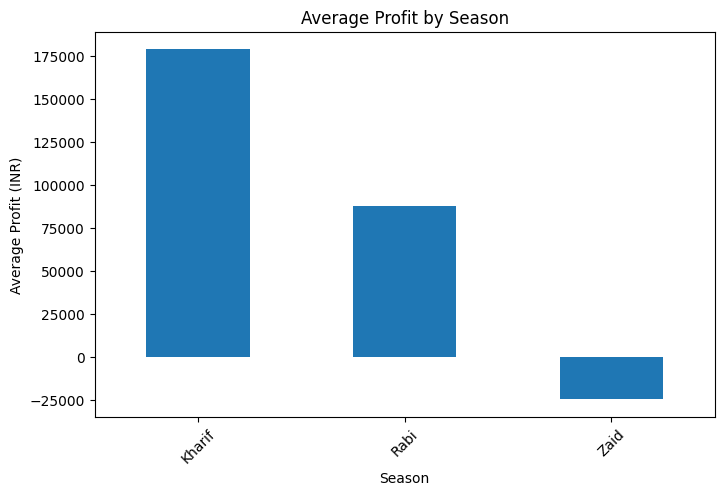

In [51]:
plt.figure(figsize=(8,5))

season_profit.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=45)
plt.show()

In [52]:
economic_summary = df_clean.groupby("Season")[
    ["Total_Cost_INR", "Revenue_INR", "Profit_INR"]
].mean()

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


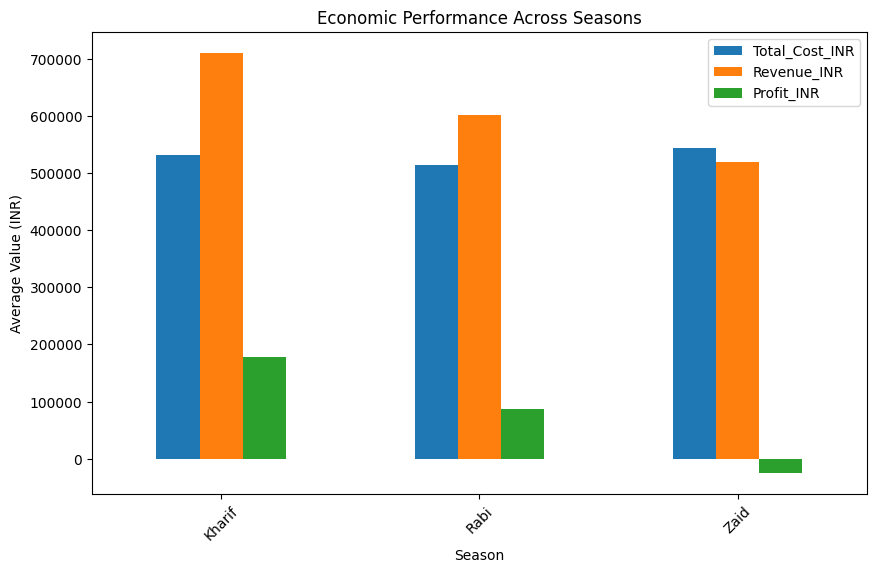

In [53]:
economic_summary.plot(kind="bar", figsize=(10,6))

plt.title("Economic Performance Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value (INR)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

In [54]:
crop_yield = df_clean.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

crop_yield

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64

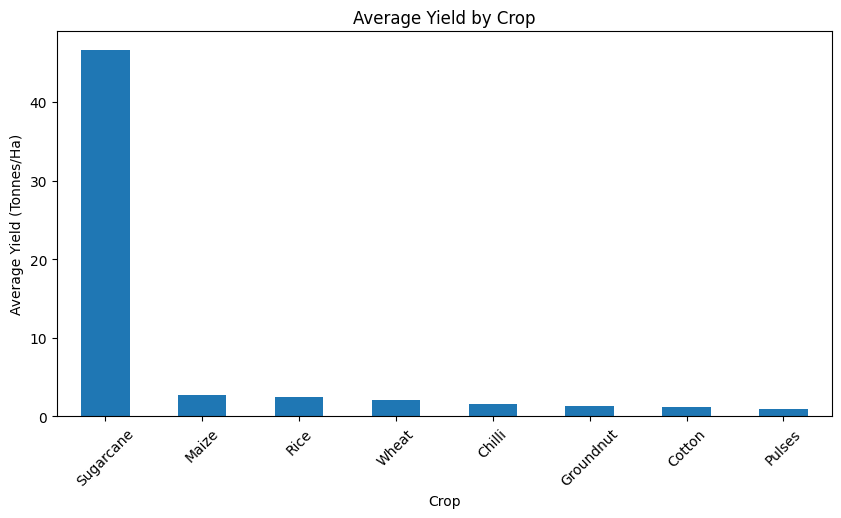

In [55]:
plt.figure(figsize=(10,5))

crop_yield.plot(kind="bar")

plt.title("Average Yield by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [56]:
crop_season_yield = pd.pivot_table(
    df_clean,
    values="Yield_Tonnes_Ha",
    index="Crop",
    columns="Season",
    aggfunc="mean"
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


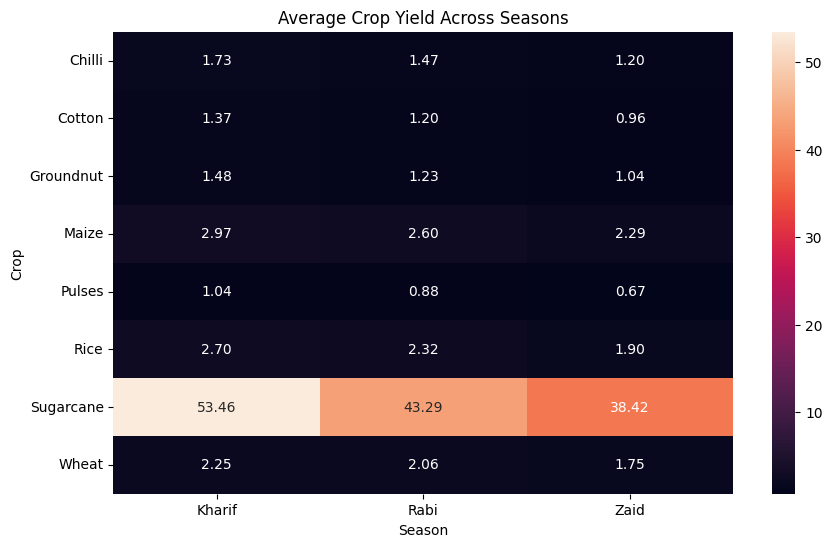

In [57]:
plt.figure(figsize=(10,6))

sns.heatmap(crop_season_yield, annot=True, fmt=".2f")

plt.title("Average Crop Yield Across Seasons")
plt.xlabel("Season")
plt.ylabel("Crop")
plt.show()

In [58]:
environment_summary = df_clean.groupby("Season")[
    [
        "Rainfall_mm",
        "Avg_Temperature_C",
        "Humidity_pct",
        "Sunlight_Hours_Day"
    ]
].mean()

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day
Season,,,,
Kharif,849.199663,28.454019,71.812591,6.793367
Rabi,437.615366,23.489183,57.893178,7.589797
Zaid,304.654714,31.042088,52.012121,8.178788


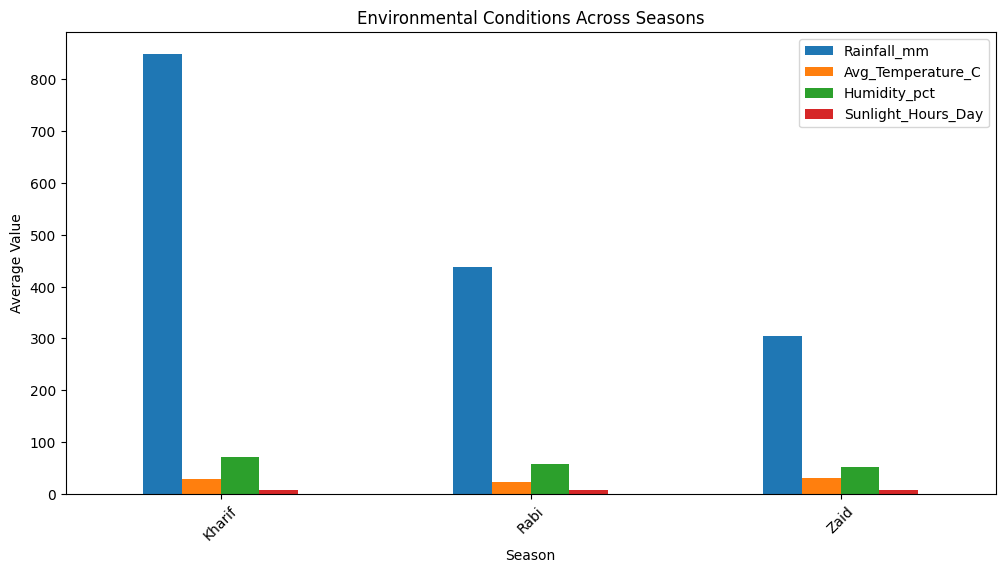

In [59]:
environment_summary.plot(kind="bar", figsize=(12,6))

plt.title("Environmental Conditions Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.legend()
plt.show()

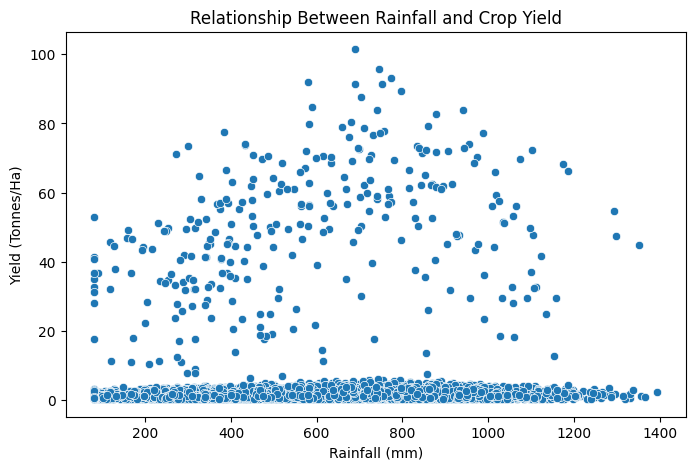

In [60]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha"
)

plt.title("Relationship Between Rainfall and Crop Yield")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

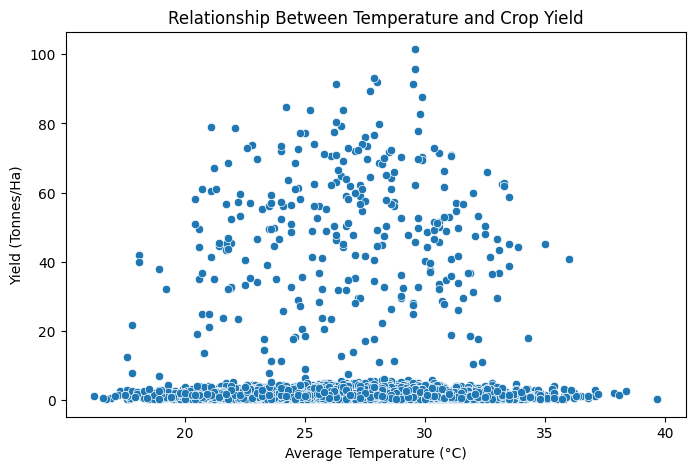

In [61]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Avg_Temperature_C",
    y="Yield_Tonnes_Ha"
)

plt.title("Relationship Between Temperature and Crop Yield")
plt.xlabel("Average Temperature (°C)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

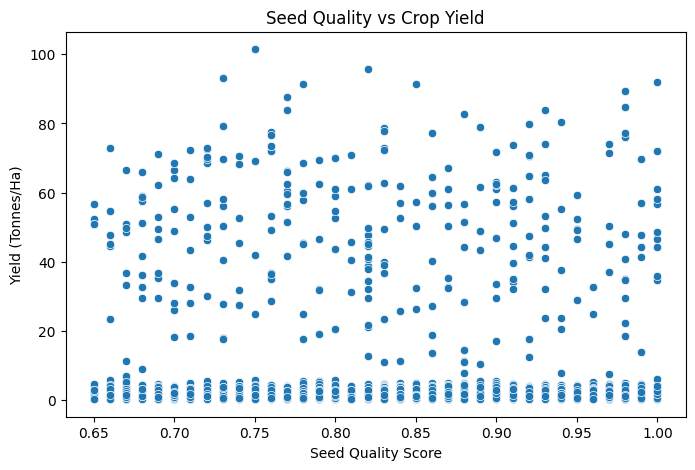

In [62]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Seed_Quality_Score",
    y="Yield_Tonnes_Ha"
)

plt.title("Seed Quality vs Crop Yield")
plt.xlabel("Seed Quality Score")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [63]:
df_clean["Irrigation_Method"].value_counts()

Irrigation_Method
Flood        1310
Rainfed      1041
Drip          915
Sprinkler     734
Name: count, dtype: int64

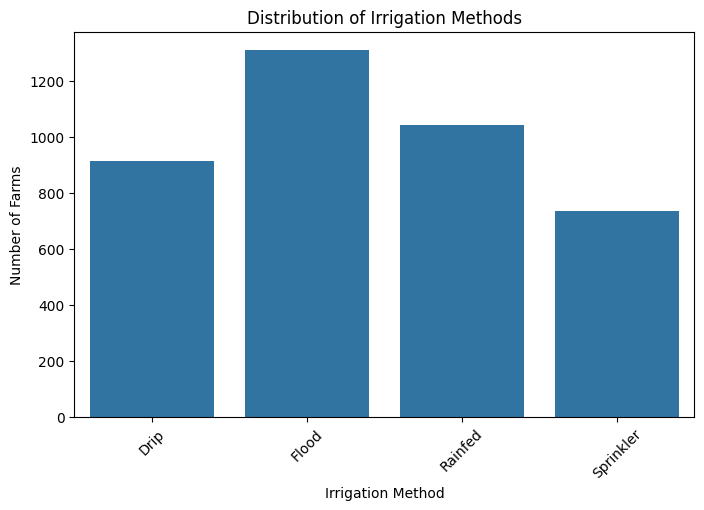

In [64]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean, x="Irrigation_Method")

plt.title("Distribution of Irrigation Methods")
plt.xlabel("Irrigation Method")
plt.ylabel("Number of Farms")
plt.xticks(rotation=45)
plt.show()

In [65]:
irrigation_yield = df_clean.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

irrigation_yield

Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64

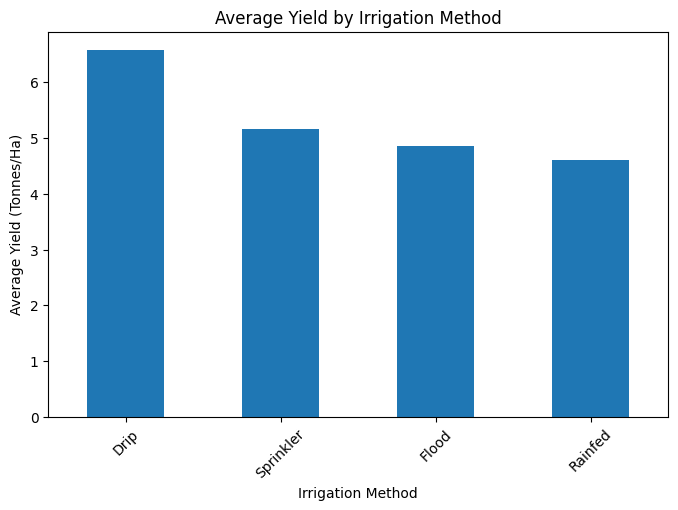

In [66]:
plt.figure(figsize=(8,5))

irrigation_yield.plot(kind="bar")

plt.title("Average Yield by Irrigation Method")
plt.xlabel("Irrigation Method")
plt.ylabel("Average Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [67]:
water_summary = df_clean.groupby("Season")[
    [
        "Water_Used_m3",
        "Water_Efficiency_t_per_1000m3"
    ]
].mean()

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


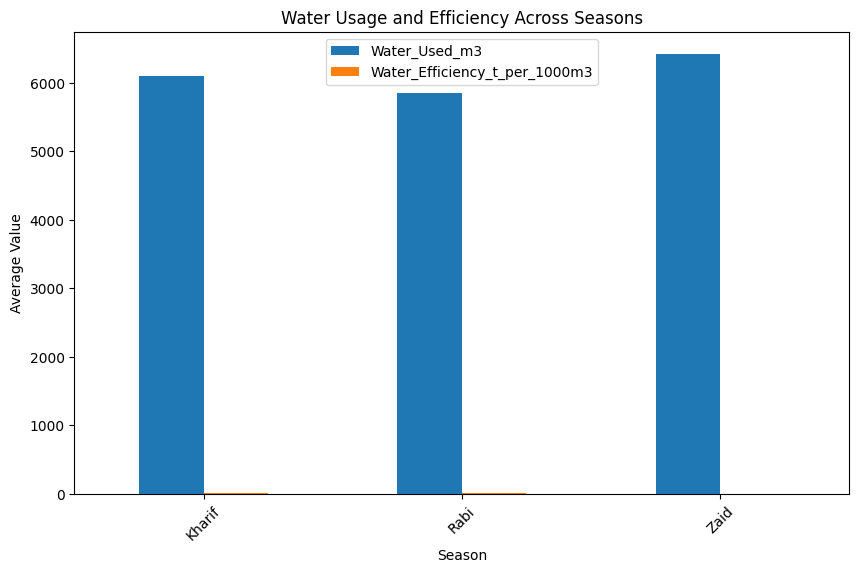

In [68]:
water_summary.plot(kind="bar", figsize=(10,6))

plt.title("Water Usage and Efficiency Across Seasons")
plt.xlabel("Season")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.show()

In [70]:
fertilizer_season = df_clean.groupby("Season")["Fertilizer_kg_ha"].mean()

fertilizer_season

Season
Kharif    187.077965
Rabi      185.407068
Zaid      184.638047
Name: Fertilizer_kg_ha, dtype: float64

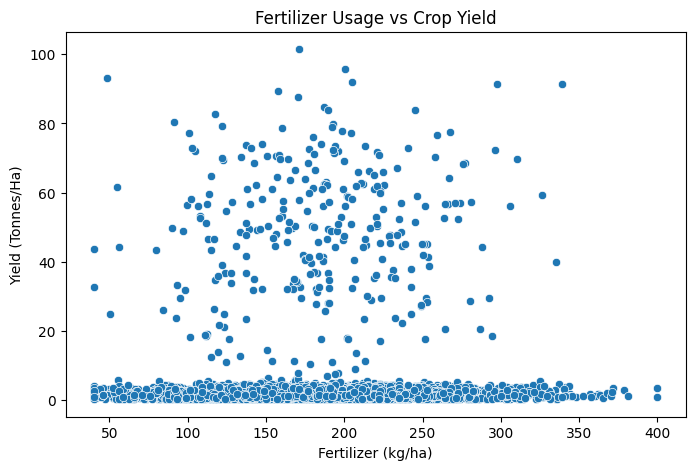

In [71]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df_clean,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha"
)

plt.title("Fertilizer Usage vs Crop Yield")
plt.xlabel("Fertilizer (kg/ha)")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

In [72]:
risk_season = df_clean.groupby("Season")["Disease_Pest_Risk_pct"].mean().sort_values(ascending=False)

risk_season

Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64

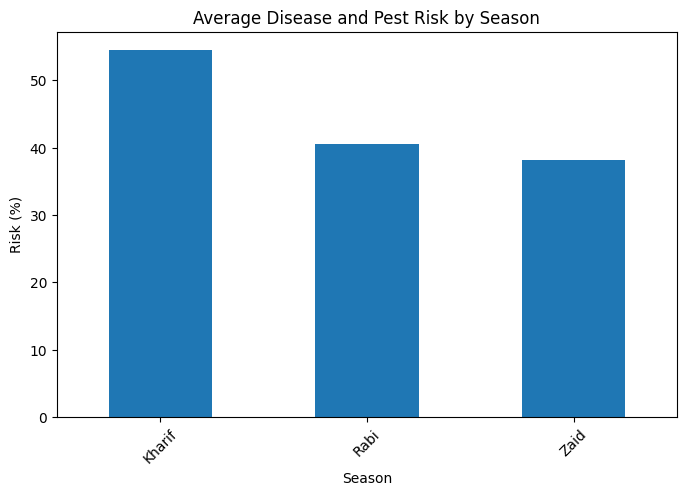

In [73]:
plt.figure(figsize=(8,5))

risk_season.plot(kind="bar")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=45)
plt.show()

In [74]:
correlation = df_clean[numerical_columns].corr()

correlation

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.000000,0.007256,0.036870,0.000471,0.001821,0.009857,0.004033,0.013658,-0.006625,0.000195,...,0.015236,0.030203,0.197842,-0.021571,0.962211,0.543364,0.115241,0.576015,0.028930,0.025963
Rainfall_mm,0.007256,1.000000,0.198492,0.521069,-0.362779,0.016657,0.508941,0.007460,0.020940,0.031373,...,-0.018581,0.030951,0.024447,0.000639,0.013041,0.098146,0.107648,0.002240,0.058102,0.621762
Avg_Temperature_C,0.036870,0.198492,1.000000,0.138136,-0.033863,0.029988,0.084001,0.018707,0.008508,0.022993,...,-0.031943,0.009996,0.007346,0.002951,0.041030,0.026703,0.009043,0.022995,0.006534,0.245613
Humidity_pct,0.000471,0.521069,0.138136,1.000000,-0.297298,0.028447,0.446470,0.001198,-0.005963,-0.003070,...,-0.045598,0.012297,0.003614,0.000262,0.006023,0.057358,0.063775,-0.002086,0.026169,0.545093
Sunlight_Hours_Day,0.001821,-0.362779,-0.033863,-0.297298,1.000000,-0.017806,-0.302846,0.009920,0.001544,-0.014407,...,0.021257,-0.015341,-0.023504,-0.000696,-0.000655,-0.047216,-0.054822,-0.005717,-0.021386,-0.253251
Soil_pH,0.009857,0.016657,0.029988,0.028447,-0.017806,1.000000,0.031183,0.006286,0.016620,-0.019407,...,-0.004181,-0.020672,-0.012512,0.022226,0.005302,-0.008798,-0.013145,-0.022859,-0.010087,0.031141
Soil_Moisture_pct,0.004033,0.508941,0.084001,0.446470,-0.302846,0.031183,1.000000,0.008884,0.013406,0.007796,...,-0.019556,0.010999,0.004787,0.016914,0.002741,0.079380,0.091281,0.003183,0.027776,0.375547
Nitrogen_kg_ha,0.013658,0.007460,0.018707,0.001198,0.009920,0.006286,0.008884,1.000000,0.010199,0.010490,...,0.014896,0.053149,0.048182,-0.022595,0.011900,0.078252,0.085016,0.022127,0.054896,-0.011503
Phosphorus_kg_ha,-0.006625,0.020940,0.008508,-0.005963,0.001544,0.016620,0.013406,0.010199,1.000000,0.002847,...,-0.007575,0.047941,0.034957,-0.005174,-0.016508,0.034940,0.049747,-0.000752,0.057129,0.032061
Potassium_kg_ha,0.000195,0.031373,0.022993,-0.003070,-0.014407,-0.019407,0.007796,0.010490,0.002847,1.000000,...,0.006862,0.003382,0.004472,0.007572,0.003431,0.028278,0.031192,0.001667,0.006575,0.013403


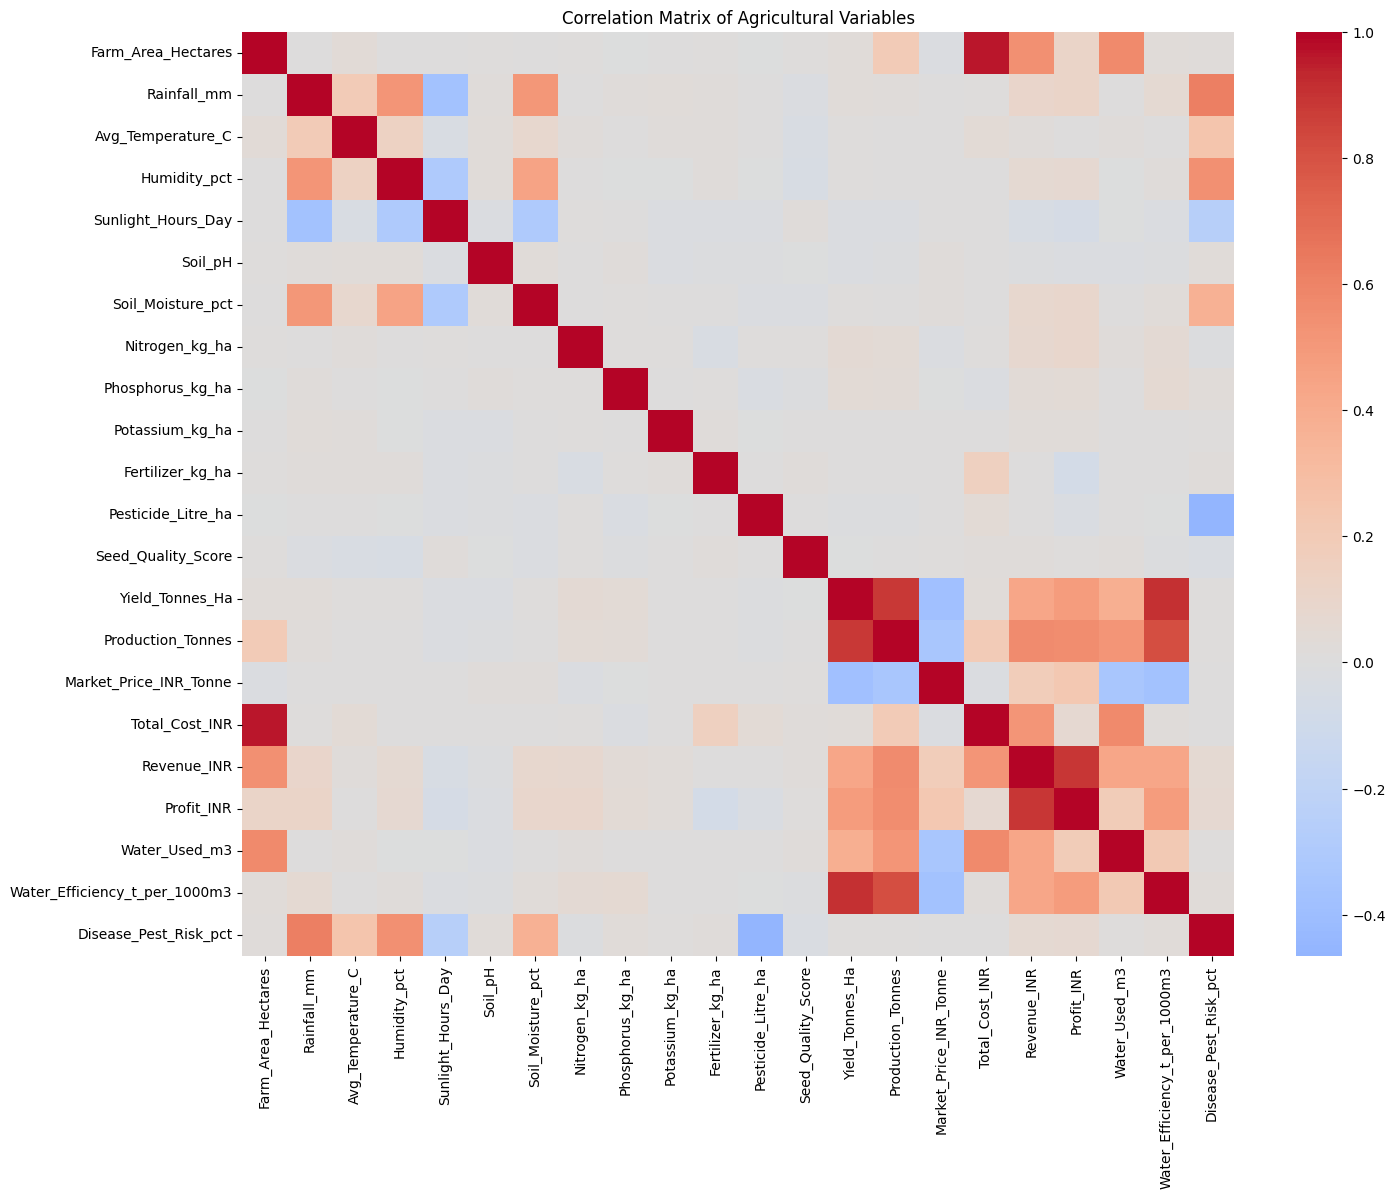

In [75]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Agricultural Variables")
plt.show()

In [76]:
yield_correlation = correlation["Yield_Tonnes_Ha"].sort_values(ascending=False)

yield_correlation

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Farm_Area_Hectares               0.030203
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64

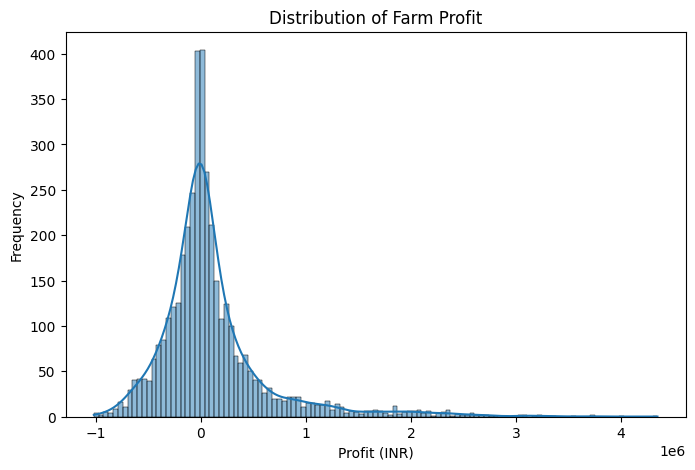

In [77]:
plt.figure(figsize=(8,5))

sns.histplot(df_clean["Profit_INR"], kde=True)

plt.title("Distribution of Farm Profit")
plt.xlabel("Profit (INR)")
plt.ylabel("Frequency")
plt.show()

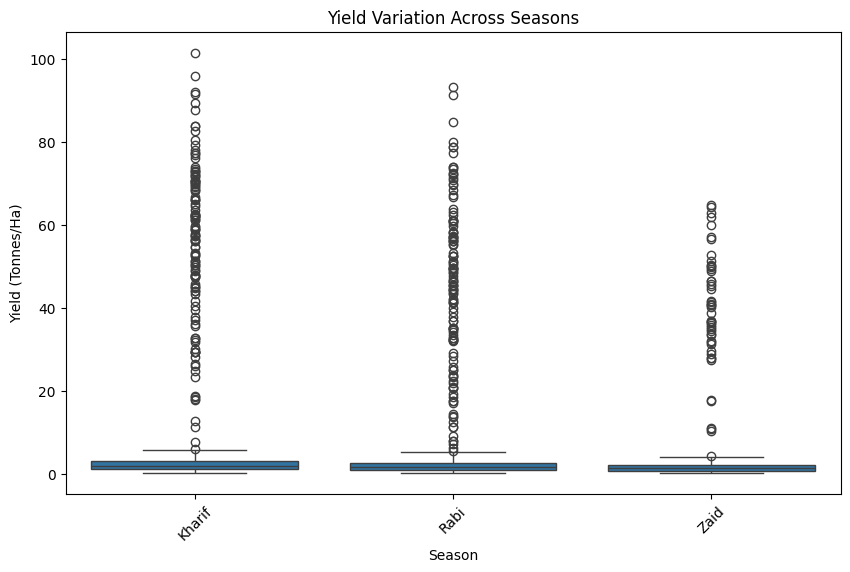

In [78]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df_clean,
    x="Season",
    y="Yield_Tonnes_Ha"
)

plt.title("Yield Variation Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.xticks(rotation=45)
plt.show()

In [79]:
state_performance = df_clean.groupby("State")[
    ["Yield_Tonnes_Ha", "Production_Tonnes", "Profit_INR"]
].mean().sort_values(
    "Yield_Tonnes_Ha",
    ascending=False
)

state_performance

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
State,,,
Punjab,6.121116,52.233099,136025.636364
Karnataka,5.685481,47.732720,119422.335378
Gujarat,5.659016,48.331988,117568.235656
Telangana,5.044477,39.254186,108829.616279
Maharashtra,5.017480,43.984043,135428.855469
Madhya Pradesh,4.989940,37.559517,86840.756539
Tamil Nadu,4.875175,40.840371,117744.748454
Andhra Pradesh,4.628771,36.913157,73453.527410


In [80]:
state_performance.head(10)

,Yield_Tonnes_Ha,Production_Tonnes,Profit_INR
State,,,
Punjab,6.121116,52.233099,136025.636364
Karnataka,5.685481,47.732720,119422.335378
Gujarat,5.659016,48.331988,117568.235656
Telangana,5.044477,39.254186,108829.616279
Maharashtra,5.017480,43.984043,135428.855469
Madhya Pradesh,4.989940,37.559517,86840.756539
Tamil Nadu,4.875175,40.840371,117744.748454
Andhra Pradesh,4.628771,36.913157,73453.527410


Question 1

Which crop performs best in each season?


In [83]:

best_crop_by_season = df_clean.groupby(
    ["Season", "Crop"]
)["Yield_Tonnes_Ha"].mean().reset_index()

best_crop_by_season.loc[
    best_crop_by_season.groupby("Season")["Yield_Tonnes_Ha"].idxmax()
]

,Season,Crop,Yield_Tonnes_Ha
6,Kharif,Sugarcane,53.459120
14,Rabi,Sugarcane,43.286124
22,Zaid,Sugarcane,38.423922


Question 2

Which irrigation method provides the highest average yield?

In [82]:


df_clean.groupby(
    "Irrigation_Method"
)["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64

Question 3

Which season provides the best economic performance?

In [84]:


df_clean.groupby("Season")[
    ["Total_Cost_INR", "Revenue_INR", "Profit_INR"]
].mean().sort_values(
    "Profit_INR",
    ascending=False
)

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


In [86]:
##Top 10 Most Profitable Farms
top_farms = df_clean[
    ["Farm_ID", "State", "District", "Crop", "Season", "Profit_INR"]
].sort_values(
    "Profit_INR",
    ascending=False
).head(10)

top_farms

,Farm_ID,State,District,Crop,Season,Profit_INR
2236,SF12237,Punjab,Rajkot,Chilli,Kharif,4345421
626,SF10627,Maharashtra,Warangal,Chilli,Kharif,4021850
3425,SF13426,Madhya Pradesh,Rajkot,Sugarcane,Kharif,3740099
1690,SF11691,Karnataka,Warangal,Chilli,Kharif,3738329
247,SF10248,Maharashtra,Krishna,Chilli,Kharif,3542204
357,SF10358,Punjab,Warangal,Sugarcane,Rabi,3378879
3423,SF13424,Andhra Pradesh,Indore,Sugarcane,Kharif,3330582
1930,SF11931,Tamil Nadu,Guntur,Sugarcane,Kharif,3232970
3983,SF13984,Gujarat,Nashik,Chilli,Kharif,3211345
263,SF10264,Maharashtra,Ludhiana,Chilli,Rabi,3159447


In [87]:
##Loss-making Farms
loss_making = df_clean[df_clean["Profit_INR"] < 0]

len(loss_making)

1966

In [88]:
loss_percentage = (
    len(loss_making) / len(df_clean)
) * 100

loss_percentage

49.15

In [89]:
##Final Seasonal Summary Table

final_season_summary = df_clean.groupby("Season").agg({
    "Yield_Tonnes_Ha": "mean",
    "Production_Tonnes": "sum",
    "Rainfall_mm": "mean",
    "Avg_Temperature_C": "mean",
    "Water_Used_m3": "mean",
    "Water_Efficiency_t_per_1000m3": "mean",
    "Total_Cost_INR": "mean",
    "Revenue_INR": "mean",
    "Profit_INR": "mean",
    "Disease_Pest_Risk_pct": "mean"
}).round(2)

final_season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Rainfall_mm,Avg_Temperature_C,Water_Used_m3,Water_Efficiency_t_per_1000m3,Total_Cost_INR,Revenue_INR,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,,,,
Kharif,5.63,82387.61,849.20,28.45,6102.20,5.89,531804.41,710719.06,178914.65,54.47
Rabi,5.04,67498.88,437.62,23.49,5846.99,5.19,513836.58,601526.05,87689.47,40.48
Zaid,4.64,23098.35,304.65,31.04,6419.89,4.41,543976.73,519171.90,-24804.82,38.22


In [91]:
df_clean.groupby("Crop")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64

In [92]:
df_clean.groupby("Irrigation_Method")["Yield_Tonnes_Ha"].mean().sort_values(ascending=False)

Irrigation_Method
Drip         6.577989
Sprinkler    5.160627
Flood        4.863977
Rainfed      4.602142
Name: Yield_Tonnes_Ha, dtype: float64

## Key Findings and Insights


1. Kharif season recorded the highest average crop yield at 5.63 tonnes/ha.

2. Kharif season recorded the highest total agricultural production at 82,387.61 tonnes.

3. Kharif season recorded the highest average profit of INR 178,914.65 per farm.

4. Sugarcane recorded the highest average crop yield at approximately 46.64 tonnes/ha.

5. Drip irrigation was associated with the highest average crop yield at approximately 6.58 tonnes/ha.

6. Water Efficiency showed the strongest relationship with crop yield, with a correlation of approximately 0.91.

7. Kharif season had the highest average disease and pest risk at 54.47%.

8. Approximately 49.15% of farms were loss-making, indicating a need for improved cost and resource management.

## Evidence-Based Recommendations

1. Seasonal crop planning should prioritize crops and farming practices that perform better during Kharif.

2. Drip irrigation should be considered where feasible because it was associated with the highest average yield of approximately 6.58 tonnes/ha in this dataset.

3. Water-use efficiency should be monitored because it showed the strongest positive relationship with crop yield.

4. Disease and pest management should be strengthened during Kharif because it recorded the highest average disease and pest risk of 54.47%.

5. Farmers with negative profits should review input costs, resource utilization, and crop selection.

6. Special attention should be given to Zaid season because its average profit was negative.

7. Crop selection should consider both yield and profitability rather than yield alone.

8. Resource utilization should be optimized to improve agricultural productivity and economic performance.

## Limitations

1. The analysis is based only on the variables available in the dataset.

2. Missing numerical values were handled using median imputation.

3. Correlation indicates association between variables and does not prove causation.

4. The dataset may not capture all real-world agricultural factors.

5. The findings are based on the available observations and may not generalize to all farms and regions.

## Limitations

1. The analysis is based only on the variables available in the dataset.

2. Missing numerical values were handled using median imputation.

3. Correlation indicates association between variables and does not prove causation.

4. The dataset may not capture all real-world agricultural factors.

5. The findings are based on the available observations and may not generalize to all farms and regions.

## Conclusion

This project analyzed agricultural performance across different seasons using data analytics techniques. The analysis examined crop yield, production, environmental conditions, farming practices, resource utilization, and economic performance.

Seasonal comparisons identified meaningful differences in yield, production, profitability, water usage, and disease/pest risk. The analysis also highlighted a strong relationship between water efficiency and crop yield and showed that irrigation method, crop selection, and season are important dimensions for agricultural planning.

These findings can support evidence-based seasonal planning, efficient resource utilization, and improved agricultural decision-making.